# `skew_normal` — pure-math layer dev notebook

Visual sanity checks for `chromhandler.fitting.skew_normal`: the centred-parameter (CP) ↔ direct-parameter (DP) bijection, density, mode, FWHM, HWHM-ratio, and the asymmetry-to-γ₁ table inversion.

Each section shows what a function is supposed to do, then plots actual outputs against either scipy's reference implementation or a numerical ground truth. Use this notebook to convince yourself the module behaves correctly before depending on it in the priors / model layers.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skewnorm

from chromhandler.fitting import skew_normal as sn

rng = np.random.default_rng(0)

print(f"GAMMA1_MAX = {sn.GAMMA1_MAX:.10f}")
print(f"scipy half-normal skew = {float(skewnorm.stats(a=1e6, moments='s')):.10f}")  # type: ignore[arg-type]

GAMMA1_MAX = 0.9952717464
scipy half-normal skew = 0.9952717464


## 1. `density_dp` — skew-normal shape as α varies

The skew-normal in direct-parameter form `(ξ, ω, α)` reduces to the standard normal at `α = 0` and approaches a half-normal as `|α| → ∞`. Plot the density for a sweep of α with `ξ=0, ω=1` to see the asymmetry develop.

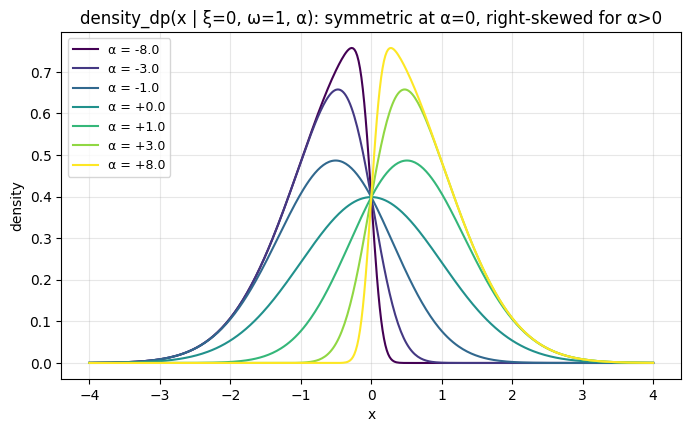

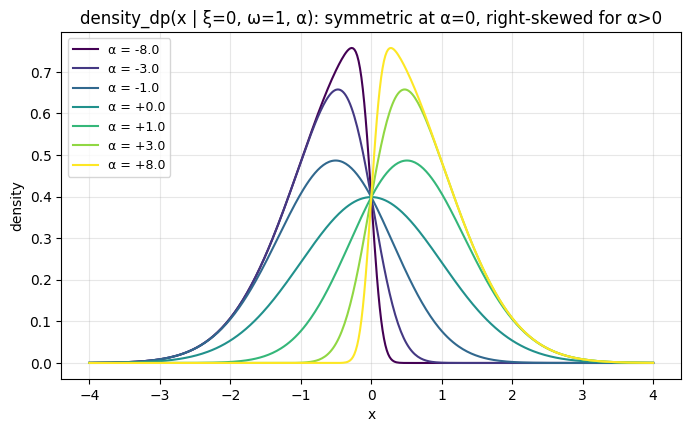

In [2]:
x = jnp.linspace(-4.0, 4.0, 401)
alphas = [-8.0, -3.0, -1.0, 0.0, 1.0, 3.0, 8.0]

fig, ax = plt.subplots(figsize=(8, 4.5))
cmap = plt.get_cmap("viridis")
for i, a in enumerate(alphas):
    f = sn.density_dp(x, jnp.asarray(0.0), jnp.asarray(1.0), jnp.asarray(a))
    ax.plot(np.asarray(x), np.asarray(f), color=cmap(i / (len(alphas) - 1)), label=f"α = {a:+.1f}")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.set_title("density_dp(x | ξ=0, ω=1, α): symmetric at α=0, right-skewed for α>0")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
fig

## 2. scipy parity — `density_dp` vs `scipy.stats.skewnorm.pdf`

Our density should match `scipy.stats.skewnorm.pdf` exactly (both implement the textbook Azzalini form). Overlay the two on a fine grid and check the residual.

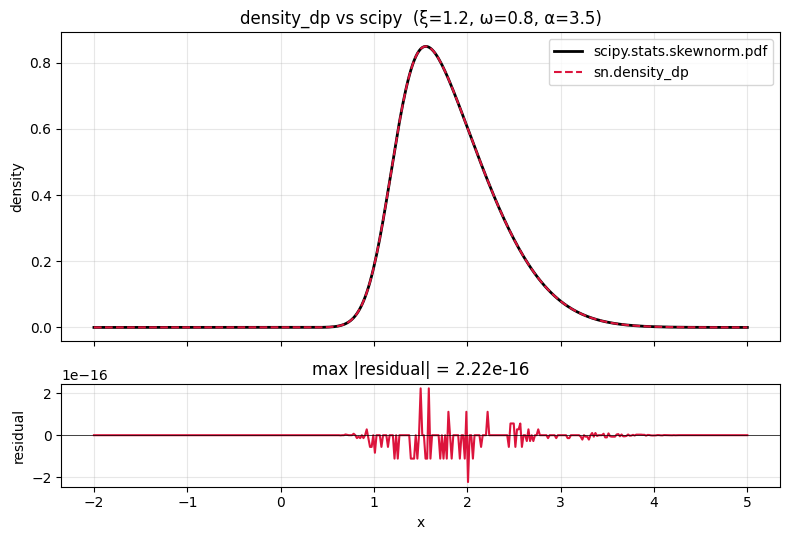

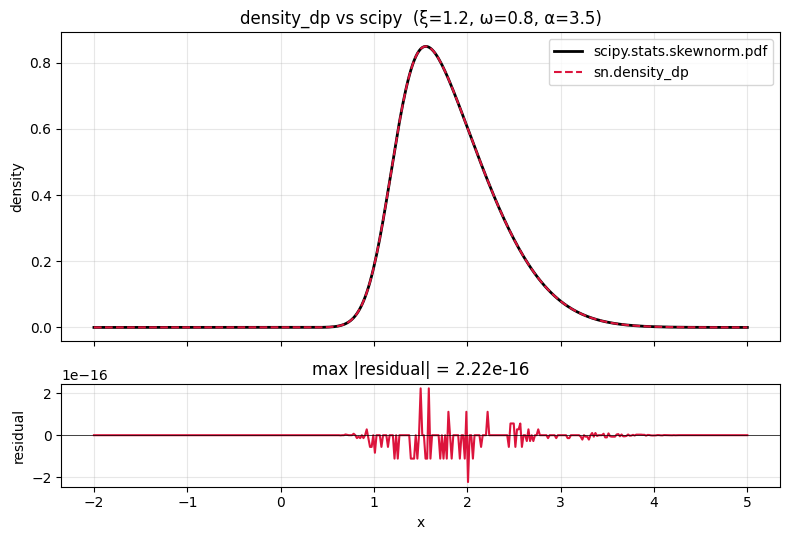

In [3]:
alpha = 3.5
xi = 1.2
omega = 0.8
x_np = np.linspace(-2.0, 5.0, 401)

ours = np.asarray(sn.density_dp(jnp.asarray(x_np), jnp.asarray(xi), jnp.asarray(omega), jnp.asarray(alpha)))
scipy_pdf = skewnorm.pdf(x_np, a=alpha, loc=xi, scale=omega)
residual = ours - scipy_pdf

fig, axes = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(x_np, scipy_pdf, label="scipy.stats.skewnorm.pdf", color="black", linewidth=2.0)
axes[0].plot(x_np, ours, label="sn.density_dp", color="crimson", linestyle="--")
axes[0].set_ylabel("density")
axes[0].set_title(f"density_dp vs scipy  (ξ={xi}, ω={omega}, α={alpha})")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(x_np, residual, color="crimson")
axes[1].axhline(0.0, color="k", linewidth=0.5)
axes[1].set_xlabel("x")
axes[1].set_ylabel("residual")
axes[1].set_title(f"max |residual| = {np.max(np.abs(residual)):.2e}")
axes[1].grid(alpha=0.3)
fig.tight_layout()
fig

## 3. Bijection — `dp_to_cp` and `cp_to_dp` round-trip

The model samples in CP `(μ, σ, γ₁)`. The density is evaluated in DP `(ξ, ω, α)`. The bijection converts between the two on every HMC leapfrog step, so it must be exact within numerical precision.

Plot 1: γ₁ as a function of α (the SN saturates at γ₁ = ±GAMMA1_MAX ≈ ±0.995).
Plot 2: round-trip error CP → DP → CP for random `(μ, σ, γ₁)` triples (should be at machine precision).

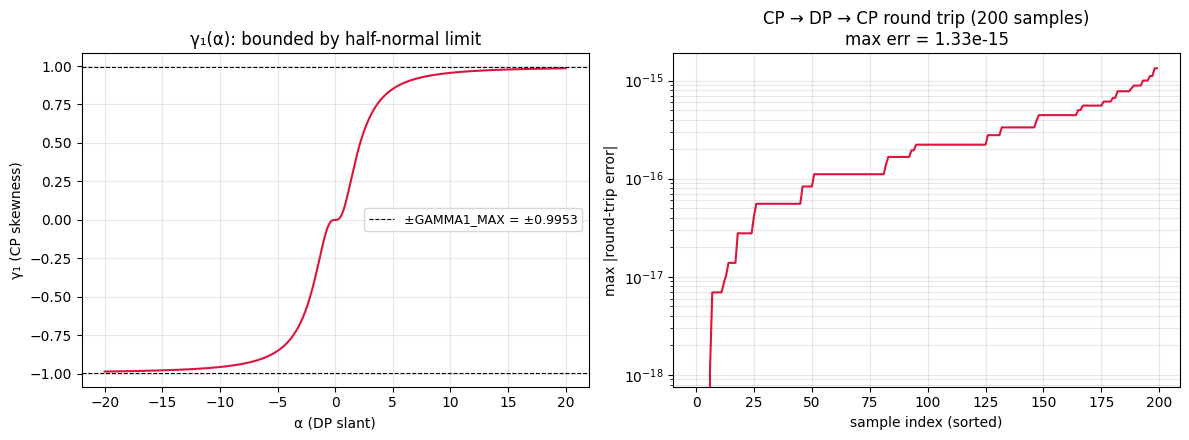

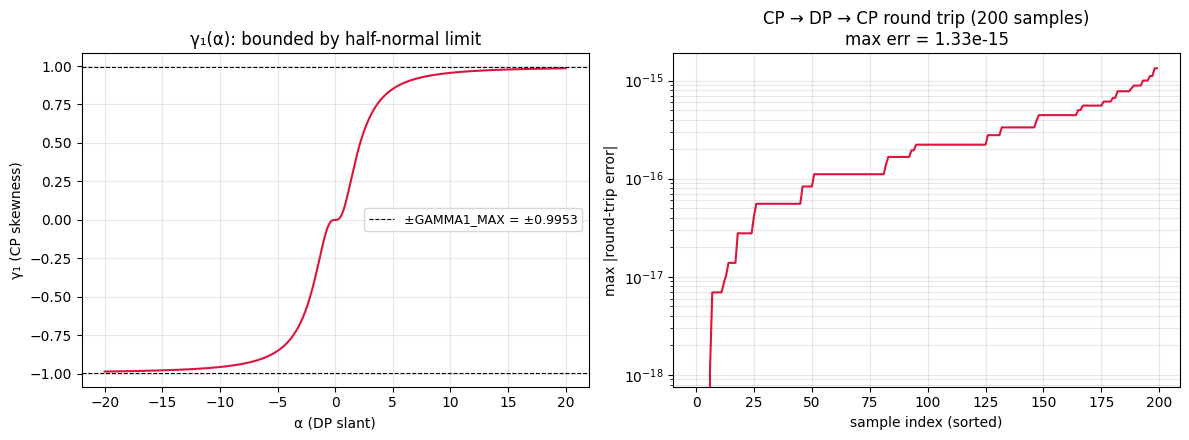

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

alpha_grid = jnp.linspace(-20.0, 20.0, 401)
_, _, gamma1_grid = sn.dp_to_cp(jnp.asarray(0.0), jnp.asarray(1.0), alpha_grid)
axes[0].plot(np.asarray(alpha_grid), np.asarray(gamma1_grid), color="crimson")
axes[0].axhline(sn.GAMMA1_MAX, color="k", linestyle="--", linewidth=0.8, label=f"±GAMMA1_MAX = ±{sn.GAMMA1_MAX:.4f}")
axes[0].axhline(-sn.GAMMA1_MAX, color="k", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("α (DP slant)")
axes[0].set_ylabel("γ₁ (CP skewness)")
axes[0].set_title("γ₁(α): bounded by half-normal limit")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

mu_in = rng.uniform(-2.0, 2.0, size=200)
sigma_in = rng.uniform(0.2, 1.5, size=200)
gamma1_in = rng.uniform(-0.95 * sn.GAMMA1_MAX, 0.95 * sn.GAMMA1_MAX, size=200)
xi_mid, omega_mid, alpha_mid = sn.cp_to_dp(jnp.asarray(mu_in), jnp.asarray(sigma_in), jnp.asarray(gamma1_in))
mu_out, sigma_out, gamma1_out = sn.dp_to_cp(xi_mid, omega_mid, alpha_mid)
errs = np.maximum.reduce([
    np.abs(np.asarray(mu_out) - mu_in),
    np.abs(np.asarray(sigma_out) - sigma_in),
    np.abs(np.asarray(gamma1_out) - gamma1_in),
])

axes[1].semilogy(np.sort(errs), color="crimson")
axes[1].set_xlabel("sample index (sorted)")
axes[1].set_ylabel("max |round-trip error|")
axes[1].set_title(f"CP → DP → CP round trip ({len(errs)} samples)\nmax err = {errs.max():.2e}")
axes[1].grid(alpha=0.3, which="both")
fig.tight_layout()
fig

## 4. Mode and FWHM — overlay on the density

`mode_dp` and `fwhm_dp` are reporting-only quantities. Visualize them on top of the density to confirm:
- The mode marker sits exactly at the peak of the curve.
- The FWHM endpoints meet the density at half the peak height.
- For α > 0 (right-skewed) the mode is *left of* the mean.

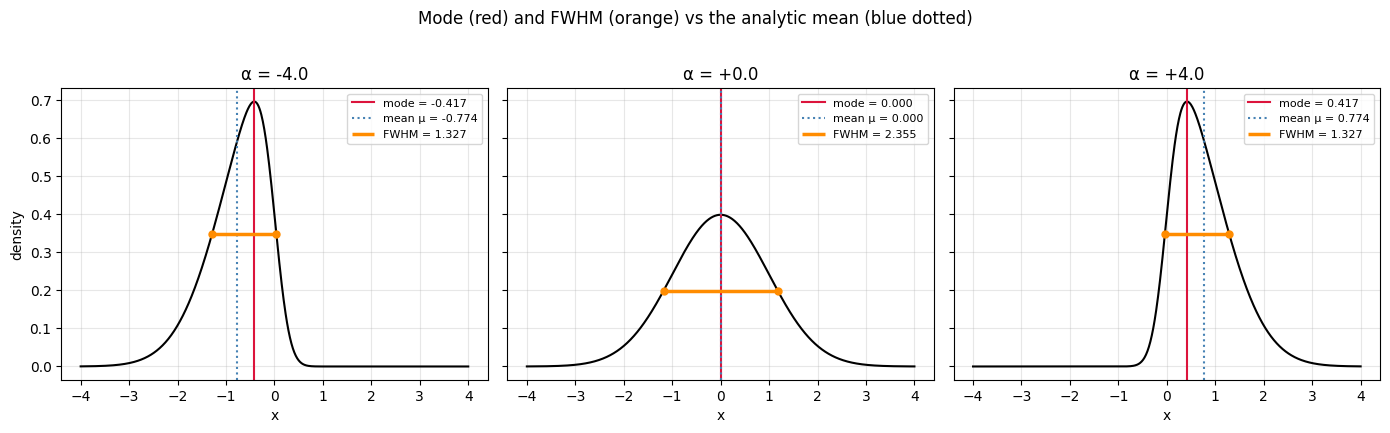

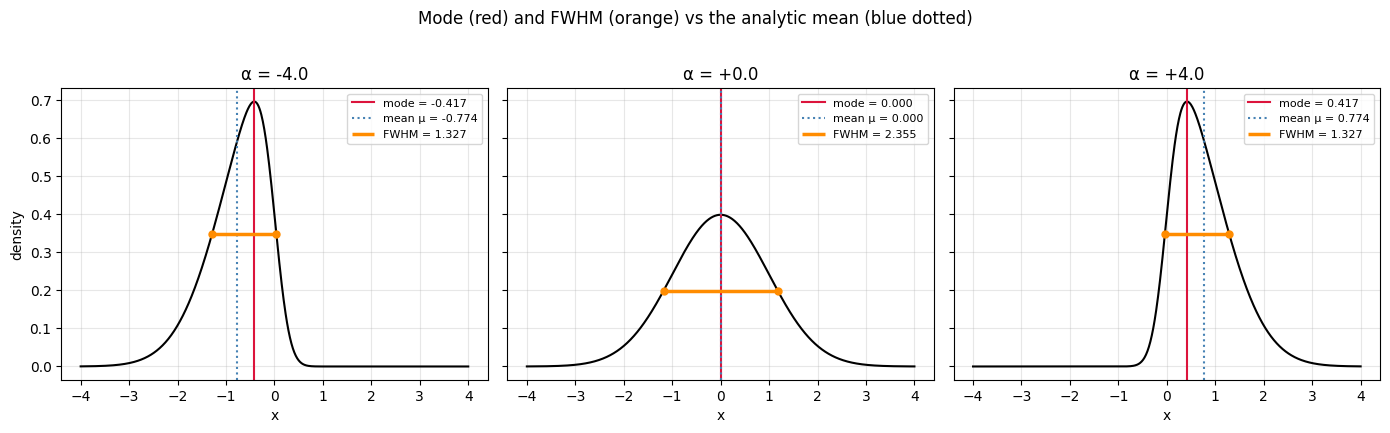

In [5]:
alphas_panel = [-4.0, 0.0, 4.0]
xi, omega = 0.0, 1.0
x_np = np.linspace(-4.0, 4.0, 801)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, a in zip(axes, alphas_panel):
    f = np.asarray(sn.density_dp(jnp.asarray(x_np), jnp.asarray(xi), jnp.asarray(omega), jnp.asarray(a)))
    mode = float(sn.mode_dp(jnp.asarray(xi), jnp.asarray(omega), jnp.asarray(a)))
    peak = float(sn.density_dp(jnp.asarray(mode), jnp.asarray(xi), jnp.asarray(omega), jnp.asarray(a)))
    w = float(sn.fwhm_dp(xi, omega, a))

    # FWHM endpoints (numerical from scipy, for visual confirmation)
    from scipy.optimize import brentq

    g = lambda v: float(skewnorm.pdf(v, a=a, loc=xi, scale=omega)) - peak / 2.0
    x_left = brentq(g, mode - 5.0 * omega, mode)
    x_right = brentq(g, mode, mode + 5.0 * omega)

    # Mean for reference
    mu, _, _ = sn.dp_to_cp(jnp.asarray(xi), jnp.asarray(omega), jnp.asarray(a))

    ax.plot(x_np, f, color="black")
    ax.axvline(mode, color="crimson", linestyle="-", label=f"mode = {mode:.3f}")
    ax.axvline(float(mu), color="steelblue", linestyle=":", label=f"mean μ = {float(mu):.3f}")
    ax.hlines(peak / 2.0, x_left, x_right, color="darkorange", linewidth=2.5, label=f"FWHM = {w:.3f}")
    ax.plot([x_left, x_right], [peak / 2.0, peak / 2.0], "o", color="darkorange", markersize=5)
    ax.set_title(f"α = {a:+.1f}")
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")
axes[0].set_ylabel("density")
fig.suptitle("Mode (red) and FWHM (orange) vs the analytic mean (blue dotted)", y=1.02)
fig.tight_layout()
fig

## 5. `hwhm_ratio_dp` — the shape descriptor used by the prior

The prior pipeline (§6.1 of the spec) measures `HWHM_R / HWHM_L` from raw data and uses it as the empirical asymmetry. The function `hwhm_ratio_dp` is the *forward* map (α → ratio) computed analytically; we need it to build the inversion table used at prior time.

Two sanity properties:
- Monotone in α (so the inverse is well-defined).
- Mirror symmetric: `ratio(−α) = 1 / ratio(α)`.

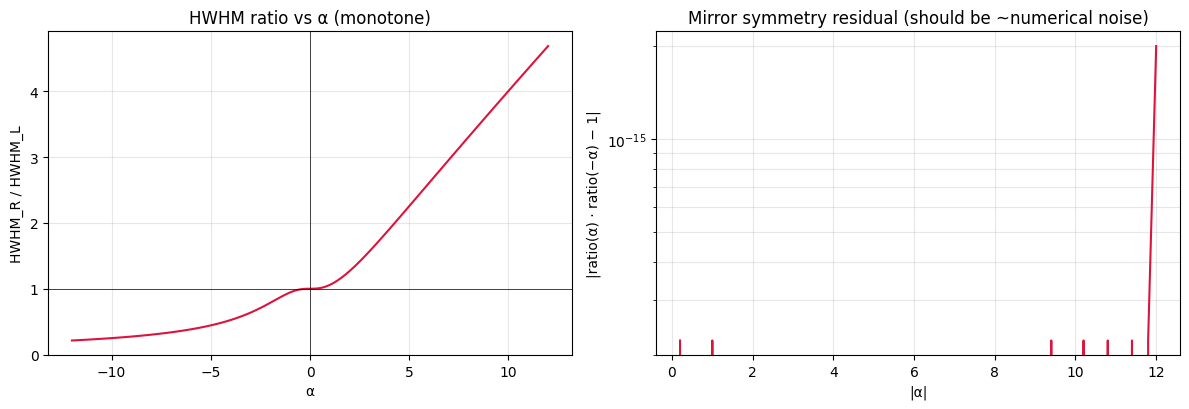

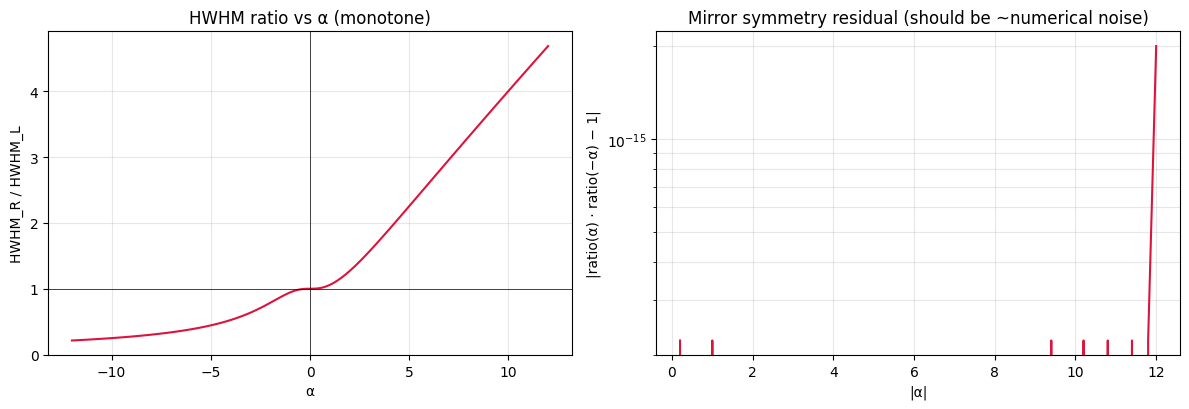

In [6]:
alpha_grid = np.linspace(-12.0, 12.0, 121)
ratios = sn.hwhm_ratio_dp(np.zeros_like(alpha_grid), np.ones_like(alpha_grid), alpha_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(alpha_grid, ratios, color="crimson")
axes[0].axhline(1.0, color="k", linewidth=0.5)
axes[0].axvline(0.0, color="k", linewidth=0.5)
axes[0].set_xlabel("α")
axes[0].set_ylabel("HWHM_R / HWHM_L")
axes[0].set_title("HWHM ratio vs α (monotone)")
axes[0].grid(alpha=0.3)

pos = alpha_grid[alpha_grid > 0]
r_pos = sn.hwhm_ratio_dp(np.zeros_like(pos), np.ones_like(pos), pos)
r_neg = sn.hwhm_ratio_dp(np.zeros_like(pos), np.ones_like(pos), -pos)
axes[1].semilogy(pos, r_pos * r_neg - 1.0, color="crimson")
axes[1].set_xlabel("|α|")
axes[1].set_ylabel("|ratio(α) · ratio(−α) − 1|")
axes[1].set_title("Mirror symmetry residual (should be ~numerical noise)")
axes[1].grid(alpha=0.3, which="both")
fig.tight_layout()
fig

## 6. `sn_asymmetry_to_gamma1` — invert measured ratio to γ₁

At prior-build time we have a *measured* HWHM ratio from raw data and need a γ₁ to put into the empirical prior. The function does a `jnp.interp` against a precomputed (ratio → γ₁) table.

Round-trip test: start from a known α, compute the ratio via `hwhm_ratio_dp`, invert back to γ₁ via `sn_asymmetry_to_gamma1`, and compare to the analytic γ₁(α) from `dp_to_cp`.

_First call triggers the table build (~5s for 401 grid points); cached afterwards._

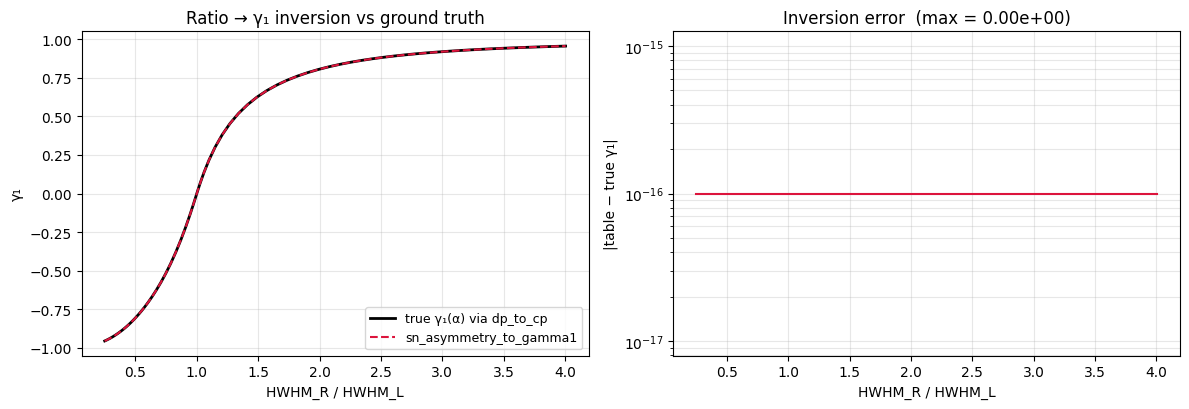

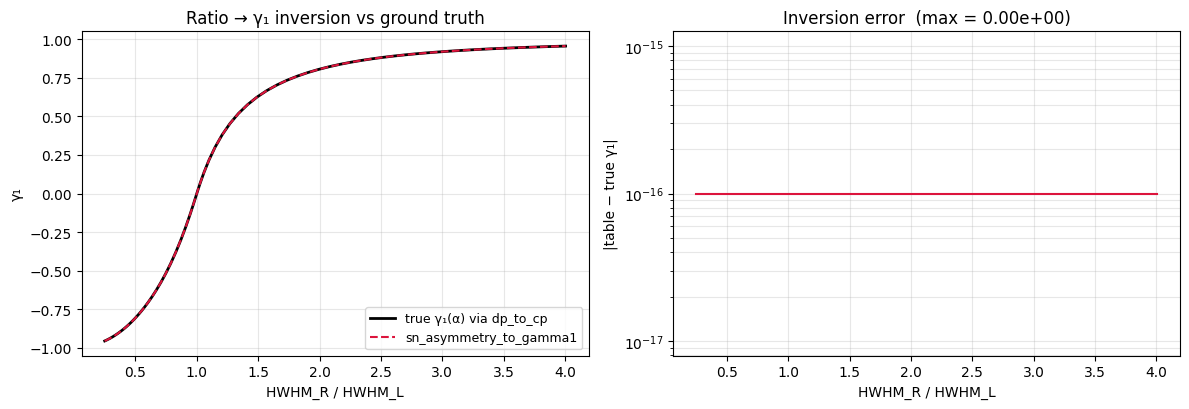

In [7]:
alpha_grid = np.linspace(-10.0, 10.0, 81)
ratios = sn.hwhm_ratio_dp(np.zeros_like(alpha_grid), np.ones_like(alpha_grid), alpha_grid)
_, _, gamma1_true = sn.dp_to_cp(jnp.asarray(0.0), jnp.asarray(1.0), jnp.asarray(alpha_grid))
gamma1_table = sn.sn_asymmetry_to_gamma1(jnp.asarray(ratios))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(ratios, np.asarray(gamma1_true), color="black", linewidth=2.0, label="true γ₁(α) via dp_to_cp")
axes[0].plot(ratios, np.asarray(gamma1_table), color="crimson", linestyle="--", label="sn_asymmetry_to_gamma1")
axes[0].set_xlabel("HWHM_R / HWHM_L")
axes[0].set_ylabel("γ₁")
axes[0].set_title("Ratio → γ₁ inversion vs ground truth")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

err = np.abs(np.asarray(gamma1_table) - np.asarray(gamma1_true))
axes[1].semilogy(ratios, err + 1e-16, color="crimson")
axes[1].set_xlabel("HWHM_R / HWHM_L")
axes[1].set_ylabel("|table − true γ₁|")
axes[1].set_title(f"Inversion error  (max = {err.max():.2e})")
axes[1].grid(alpha=0.3, which="both")
fig.tight_layout()
fig

## 7. Simulated peaks — recovering γ₁ from noisy data, the way `priors.py` will

Honest dry run of the prior pipeline. For four CP scenarios `(μ, σ, γ₁)`:

1. Simulate `n_trace = 8` noisy traces of `A · density_cp(t | μ, σ, γ₁) + N(0, σ_noise)`. Noise level chosen so peak S/N ≈ 15, comparable to a real low-concentration chromatogram.
2. Per trace, **on the noisy data** (no cheating with the clean curve): smooth lightly, find apex by argmax, walk outward and linearly interpolate the half-max crossings, compute `HWHM_R / HWHM_L`, invert via `sn_asymmetry_to_gamma1`.
3. Aggregate: report `mean ± std` of the per-trace γ₁ estimates and compare to the true value.

This is what spec §6.1 / §6.2 actually does — per-trace estimates are noisy and biased, but averaging across traces recovers the true population shape. Top row: one noisy trace per scenario with its measured HWHM bracket. Bottom row: per-trace γ₁ estimates as a strip plot, with the population mean and the truth as horizontal lines.

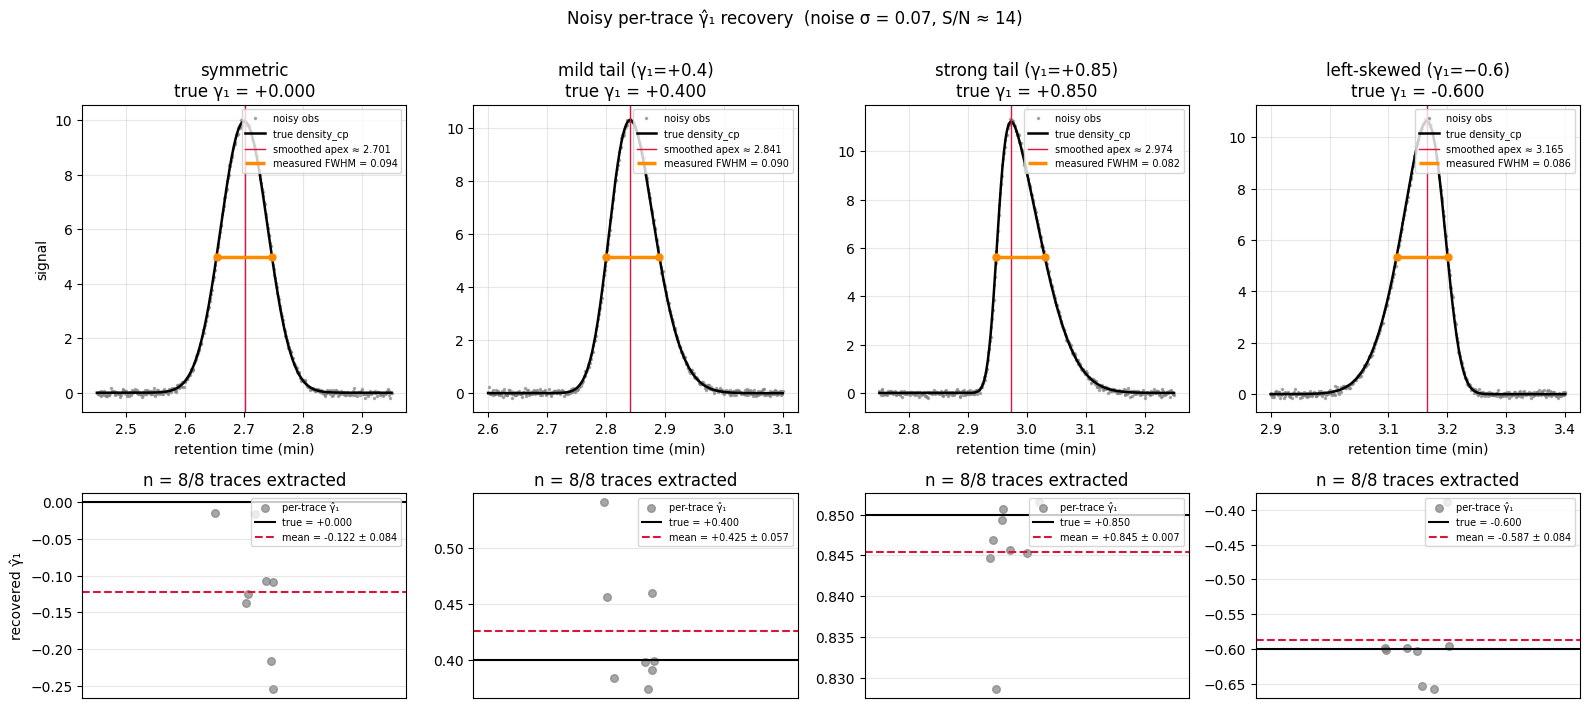

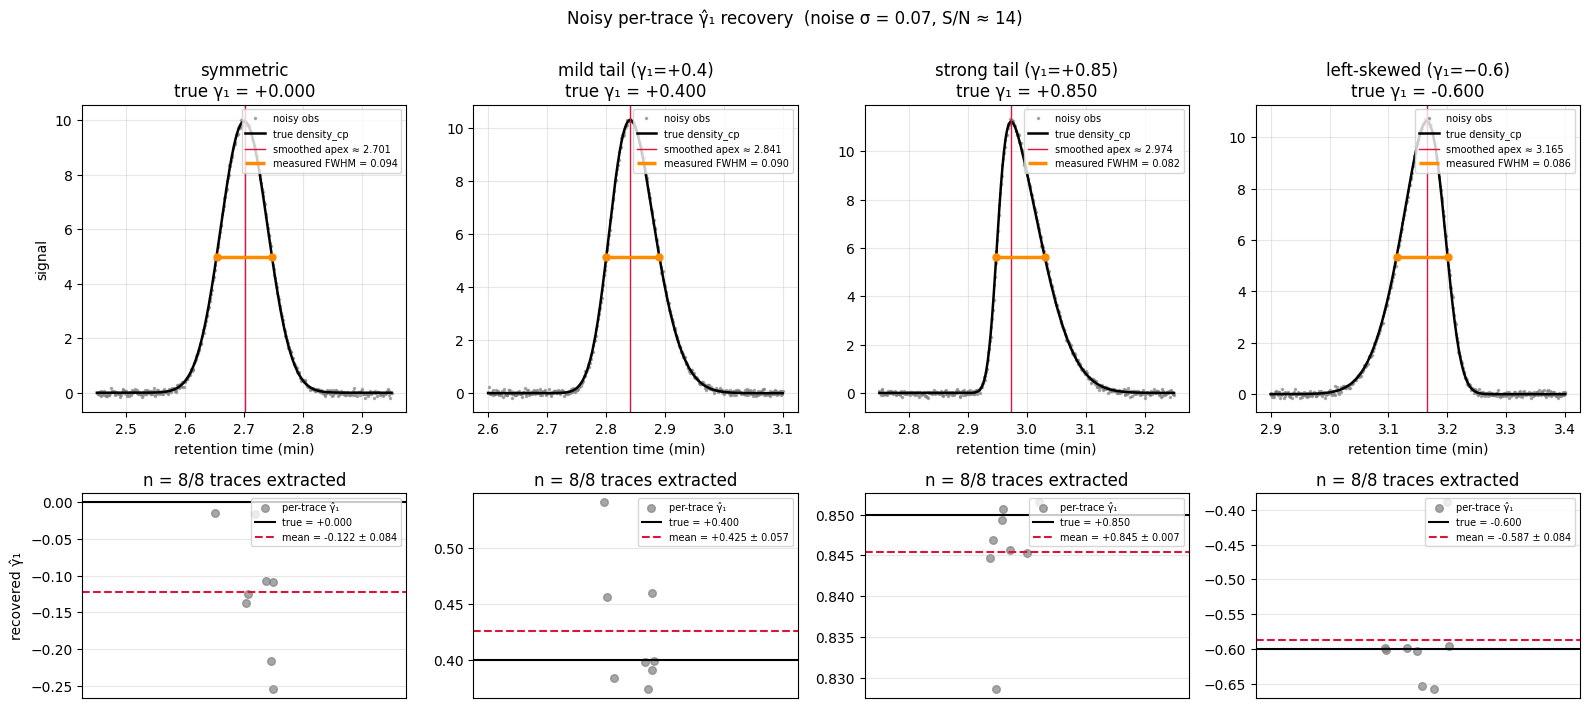

In [8]:
from scipy.ndimage import uniform_filter1d


def measure_hwhm_ratio(t, y, smoothing=5):
    """Mimic the per-trace HWHM extraction the prior pipeline will use.

    Smooth lightly, find apex via argmax on smoothed signal, walk outward
    from the apex and linearly interpolate the half-max crossings. Returns
    (ratio, t_apex, t_left, t_right, half) or None if extraction fails.
    """
    s = uniform_filter1d(y, size=smoothing)
    i_apex = int(np.argmax(s))
    h = s[i_apex]
    if h <= 0:
        return None
    half = h / 2.0

    # Walk left
    i = i_apex
    while i > 0 and s[i] > half:
        i -= 1
    if i == 0 and s[0] > half:
        return None
    f = (s[i + 1] - half) / (s[i + 1] - s[i]) if s[i + 1] != s[i] else 0.0
    t_left = t[i + 1] - f * (t[i + 1] - t[i])

    # Walk right
    i = i_apex
    while i < len(s) - 1 and s[i] > half:
        i += 1
    if i == len(s) - 1 and s[i] > half:
        return None
    f = (s[i - 1] - half) / (s[i - 1] - s[i]) if s[i - 1] != s[i] else 0.0
    t_right = t[i - 1] + f * (t[i] - t[i - 1])

    t_apex = t[i_apex]
    hwhm_L = t_apex - t_left
    hwhm_R = t_right - t_apex
    if hwhm_L <= 0 or hwhm_R <= 0:
        return None
    return hwhm_R / hwhm_L, t_apex, t_left, t_right, half


scenarios = [
    {"label": "symmetric",             "mu": 2.70, "sigma": 0.040, "gamma1":  0.00, "A": 1.0},
    {"label": "mild tail (γ₁=+0.4)",   "mu": 2.85, "sigma": 0.040, "gamma1":  0.40, "A": 1.0},
    {"label": "strong tail (γ₁=+0.85)","mu": 3.00, "sigma": 0.040, "gamma1":  0.85, "A": 1.0},
    {"label": "left-skewed (γ₁=−0.6)", "mu": 3.15, "sigma": 0.040, "gamma1": -0.60, "A": 1.0},
]
n_trace = 8
noise = 0.07  # peak height ~1.0 (depends on sigma & gamma1), so S/N ≈ 12–17

fig, axes = plt.subplots(2, len(scenarios), figsize=(4.0 * len(scenarios), 7.0),
                         gridspec_kw={"height_ratios": [3, 2]})

for col, sc in enumerate(scenarios):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    t = np.linspace(sc["mu"] - 0.25, sc["mu"] + 0.25, 401)
    clean = sc["A"] * np.asarray(
        sn.density_cp(jnp.asarray(t), jnp.asarray(sc["mu"]),
                      jnp.asarray(sc["sigma"]), jnp.asarray(sc["gamma1"]))
    )

    per_trace_gamma1 = []
    last_extraction = None
    for k in range(n_trace):
        obs = clean + rng.normal(0.0, noise, size=t.size)
        result = measure_hwhm_ratio(t, obs)
        if result is None:
            continue
        ratio, t_apex, t_left, t_right, half = result
        g_hat = float(sn.sn_asymmetry_to_gamma1(jnp.asarray(ratio)))
        per_trace_gamma1.append(g_hat)
        if last_extraction is None:
            last_extraction = (obs, t_apex, t_left, t_right, half)

    per_trace_gamma1 = np.asarray(per_trace_gamma1)
    g_mean = per_trace_gamma1.mean() if per_trace_gamma1.size else np.nan
    g_std = per_trace_gamma1.std(ddof=1) if per_trace_gamma1.size > 1 else 0.0
    g_true = sc["gamma1"]

    # Top: one noisy trace with the measured HWHM bracket
    if last_extraction is not None:
        obs, t_apex, t_left, t_right, half = last_extraction
        ax_top.plot(t, obs, ".", color="gray", markersize=3, alpha=0.6, label="noisy obs")
        ax_top.plot(t, clean, color="black", linewidth=1.8, label="true density_cp")
        ax_top.axvline(t_apex, color="crimson", linewidth=1.0, label=f"smoothed apex ≈ {t_apex:.3f}")
        ax_top.hlines(half, t_left, t_right, color="darkorange", linewidth=2.5,
                      label=f"measured FWHM = {t_right - t_left:.3f}")
        ax_top.plot([t_left, t_right], [half, half], "o", color="darkorange", markersize=5)
    ax_top.set_title(f"{sc['label']}\ntrue γ₁ = {g_true:+.3f}")
    ax_top.set_xlabel("retention time (min)")
    if col == 0:
        ax_top.set_ylabel("signal")
    ax_top.grid(alpha=0.3)
    ax_top.legend(fontsize=7, loc="upper right")

    # Bottom: per-trace γ₁ estimates as a strip plot
    jitter = rng.uniform(-0.15, 0.15, size=per_trace_gamma1.size)
    ax_bot.scatter(jitter, per_trace_gamma1, color="gray", s=30, alpha=0.7, label="per-trace γ̂₁")
    ax_bot.axhline(g_true, color="black", linestyle="-", linewidth=1.5, label=f"true = {g_true:+.3f}")
    ax_bot.axhline(g_mean, color="crimson", linestyle="--", linewidth=1.5,
                   label=f"mean = {g_mean:+.3f} ± {g_std:.3f}")
    ax_bot.set_xlim(-0.6, 0.6)
    ax_bot.set_xticks([])
    if col == 0:
        ax_bot.set_ylabel("recovered γ̂₁")
    ax_bot.set_title(f"n = {per_trace_gamma1.size}/{n_trace} traces extracted")
    ax_bot.grid(alpha=0.3, axis="y")
    ax_bot.legend(fontsize=7, loc="upper right")

fig.suptitle(f"Noisy per-trace γ̂₁ recovery  (noise σ = {noise}, S/N ≈ {1.0 / noise:.0f})", y=1.005)
fig.tight_layout()
fig

## 8. Differentiability — `jax.grad` through `density_dp`

The whole point of staying inside JAX is that the model layer can backprop through the density. Sanity-check that `jax.grad` produces finite gradients w.r.t. each DP parameter.

In [9]:
x0 = jnp.asarray(0.5)
xi0 = jnp.asarray(0.0)
omega0 = jnp.asarray(1.0)
alpha0 = jnp.asarray(2.0)

g_xi = jax.grad(lambda v: sn.density_dp(x0, v, omega0, alpha0))(xi0)
g_omega = jax.grad(lambda v: sn.density_dp(x0, xi0, v, alpha0))(omega0)
g_alpha = jax.grad(lambda v: sn.density_dp(x0, xi0, omega0, v))(alpha0)

print(f"∂f/∂ξ  at (x=0.5, ξ=0, ω=1, α=2) = {float(g_xi):+.6f}")
print(f"∂f/∂ω  at (x=0.5, ξ=0, ω=1, α=2) = {float(g_omega):+.6f}")
print(f"∂f/∂α  at (x=0.5, ξ=0, ω=1, α=2) = {float(g_alpha):+.6f}")

∂f/∂ξ  at (x=0.5, ξ=0, ω=1, α=2) = -0.044550
∂f/∂ω  at (x=0.5, ξ=0, ω=1, α=2) = -0.614691
∂f/∂α  at (x=0.5, ξ=0, ω=1, α=2) = +0.085190


## What's next

With the math layer trusted, the next module up is `priors.py` (spec §7.2): per-trace FWHM-based feature extraction, population aggregation, and the `SkewNormalPriors` dataclass. That's the layer that turns the foundations dataset + this module into actual prior `(loc, scale)` for HMC.